# Pręt pryzmatyczny obciążony osiowo — PINN

$$EA\,u''(x) + p(x) = 0,\qquad x\in[-1,1],\qquad u(\pm1)=0,\qquad p(x)=\pi^2\sin(\pi x),\qquad EA=\text{const}$$

**Rozwiązanie analityczne**

$$\begin{aligned}
EA\,u''(x) &= -\pi^2\sin(\pi x)\\
EA\,u'(x) &= \pi\cos(\pi x) + C_1\\
EA\,u(x) &= \sin(\pi x) + C_1 x + C_2
\end{aligned}$$

$$u(-1)=0:\;\; -C_1 + C_2 = 0,\qquad u(1)=0:\;\; C_1 + C_2 = 0\qquad\Rightarrow\qquad C_1 = C_2 = 0$$

$$u(x)=\frac{\sin(\pi x)}{EA},\qquad N(x)=EA\,u'(x)=\pi\cos(\pi x)$$

In [3]:
import os
os.environ["DDE_BACKEND"] = "pytorch"

import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import deepxde as dde

SEED = 0
dde.config.set_random_seed(SEED)
EA = 1.0

ITERATIONS = 2000   # liczba iteracji (epok)
LR = 1e-3           # krok uczenia (Adam)
WIDTH = 50          # neurony w warstwie ukrytej (3 warstwy)
N_COL = 15          # punkty kolokacyjne
w_pde, w_bc = 1, 1   # wagi składników kosztu: L = w_pde*L_PDE + w_bc*L_BC

USE_EXACT = True

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


### Plan demo

1. Na jedynkach: `EA = 1`, `w_pde, w_bc = 1, 1` — od razu pokazać też PyTorch
2. Zmienić `LR`
3. Zmienić sztywność na `EA = 1e3`
4. Zmienić wagi: `w_pde = 1e-6`

## 1. DeepXDE

In [6]:
geom = dde.geometry.Interval(-1, 1)

# reszta z równania równowagi
def pde(x, u):
    u_xx = dde.grad.hessian(u, x)
    p = math.pi**2 * torch.sin(math.pi * x)
    return EA * u_xx + p

# rozwiązanie dokładne (tylko do testowania)
def u_exact(x):
    return np.sin(np.pi * x) / EA

# warunki brzegowe
bc = dde.icbc.DirichletBC(geom, lambda x: 0.0, lambda x, on_boundary: on_boundary)

# składamy nasze dane do modelu DeepXDE
data = dde.data.PDE(geom, pde, [bc], num_domain=N_COL, num_boundary=2,
                    solution=u_exact if USE_EXACT else None, num_test=100)

# definiujemy sieć neuronową
net = dde.nn.FNN([1] + [WIDTH] * 3 + [1], "tanh", "Glorot uniform")

# inicjalizujemy model DeepXDE oraz kompilujemy go z wybranym optymalizatorem i wagami składników kosztu
model = dde.Model(data, net)
model.compile("adam", lr=LR,
              metrics=["l2 relative error"] if USE_EXACT else None,
              loss_weights=[w_pde, w_bc])

# trenujemy model i zapisujemy historię kosztu oraz stan uczenia
losshistory, train_state = model.train(iterations=ITERATIONS, display_every=ITERATIONS // 20)

Compiling model...
'compile' took 0.000117 s

Training model...

Step      Train loss              Test loss               Test metric   
0         [4.52e+01, 1.14e-02]    [4.85e+01, 1.14e-02]    [9.27e-01]    
100       [7.05e-01, 9.45e-03]    [4.22e-01, 9.45e-03]    [1.19e-01]    
200       [1.29e-01, 1.72e-03]    [6.39e-02, 1.72e-03]    [3.94e-02]    
300       [1.84e-02, 9.72e-05]    [1.21e-02, 9.72e-05]    [9.12e-03]    
400       [6.34e-03, 2.71e-05]    [4.35e-03, 2.71e-05]    [4.79e-03]    
500       [2.50e-03, 7.57e-06]    [1.95e-03, 7.57e-06]    [2.51e-03]    
600       [1.49e-03, 2.35e-06]    [1.42e-03, 2.35e-06]    [1.41e-03]    
700       [1.05e-03, 1.04e-06]    [1.12e-03, 1.04e-06]    [9.56e-04]    
800       [7.46e-04, 6.07e-07]    [8.68e-04, 6.07e-07]    [7.42e-04]    
900       [5.30e-04, 3.85e-07]    [6.70e-04, 3.85e-07]    [6.00e-04]    
1000      [3.79e-04, 2.42e-07]    [5.24e-04, 2.42e-07]    [4.84e-04]    
1100      [9.46e-04, 3.43e-05]    [1.21e-03, 3.43e-05]    [

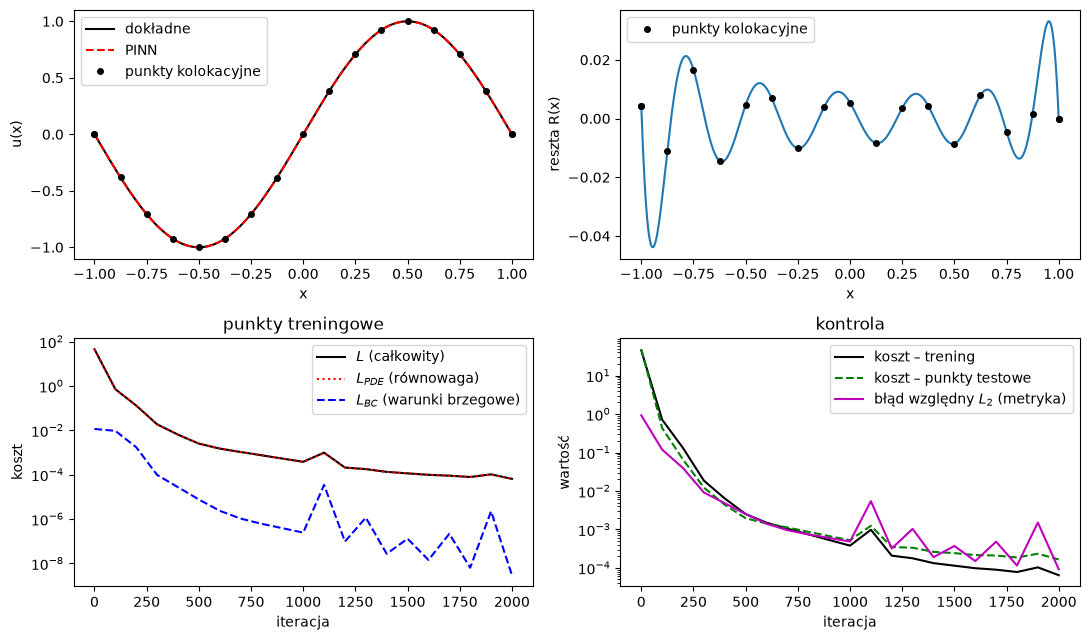

In [7]:
x = geom.uniform_points(500, True)
u_dde = model.predict(x)
R_dde = model.predict(x, operator=pde)
steps = losshistory.steps
L_tr = np.array(losshistory.loss_train)
L_te = np.array(losshistory.loss_test)

fig, ax = plt.subplots(2, 2, figsize=(11, 6.5))

a = ax[0, 0]
if USE_EXACT:
    a.plot(x, u_exact(x), "k-", label="dokładne")
a.plot(x, u_dde, "r--", label="PINN")
a.plot(train_state.X_train, model.predict(train_state.X_train), "ko", ms=4, label="punkty kolokacyjne")
a.set(xlabel="x", ylabel="u(x)"); a.legend()

a = ax[0, 1]
a.plot(x, R_dde)
a.plot(train_state.X_train, model.predict(train_state.X_train, operator=pde), "ko", ms=4, label="punkty kolokacyjne")
a.set(xlabel="x", ylabel="reszta R(x)"); a.legend()

a = ax[1, 0]
a.semilogy(steps, L_tr.sum(axis=1), "k-", label="$L$ (całkowity)")
a.semilogy(steps, L_tr[:, 0], "r:", label="$L_{PDE}$ (równowaga)")
a.semilogy(steps, L_tr[:, 1], "b--", label="$L_{BC}$ (warunki brzegowe)")
a.set(xlabel="iteracja", ylabel="koszt", title="punkty treningowe"); a.legend()

a = ax[1, 1]
a.semilogy(steps, L_tr.sum(axis=1), "k-", label="koszt – trening")
a.semilogy(steps, L_te.sum(axis=1), "g--", label="koszt – punkty testowe")
if USE_EXACT:
    a.semilogy(steps, np.array(losshistory.metrics_test)[:, 0], "m-", label="błąd względny $L_2$ (metryka)")
a.set(xlabel="iteracja", ylabel="wartość", title="kontrola"); a.legend()

fig.tight_layout()

## 2. PyTorch

In [9]:
# ziarno losowania (to samo co w DeepXDE)
torch.manual_seed(SEED)

class PINN(torch.nn.Module):
    # architektura sieci
    def __init__(self):
        super().__init__()
        self.dense1 = torch.nn.Linear(1, WIDTH)
        self.dense2 = torch.nn.Linear(WIDTH, WIDTH)
        self.dense3 = torch.nn.Linear(WIDTH, WIDTH)
        self.out = torch.nn.Linear(WIDTH, 1)
        self.act = torch.nn.Tanh()
        for layer in [self.dense1, self.dense2, self.dense3, self.out]:
            torch.nn.init.xavier_uniform_(layer.weight)
            torch.nn.init.zeros_(layer.bias)
    
    # propagacja w przód jak używamy model(X) w pętli treningowej
    def forward(self, x):
        x = self.act(self.dense1(x))
        x = self.act(self.dense2(x))
        x = self.act(self.dense3(x))
        return self.out(x)

# reszta z równania równowagi
def pde(x, u):
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    p = math.pi**2 * torch.sin(math.pi * x)
    return EA * u_xx + p

# funkcja kosztu: reszta równania w punktach kolokacyjnych + warunki brzegowe
def loss(model, X, n_bc):
    u = model(X)
    R = pde(X, u)
    L_pde = torch.mean(R[n_bc:] ** 2)
    L_bc = torch.mean(u[:n_bc] ** 2)
    return w_pde * L_pde + w_bc * L_bc

# inicjalizujemy model i optymalizator
model = PINN()
opt = torch.optim.Adam(model.parameters(), lr=LR)

# punkty: najpierw brzegowe, potem wszystkie punkty kolokacyjne (z brzegiem)
x_bc = torch.tensor([-1.0, 1.0])
x_all = torch.linspace(-1, 1, N_COL + 2)
X = torch.cat([x_bc, x_all]).reshape(-1, 1).requires_grad_(True)
n_bc = len(x_bc)

# pętla treningowa
hist = []
for it in range(ITERATIONS):
    # przywracamy gradienty do zera
    opt.zero_grad()
    # liczymy koszt
    L = loss(model, X, n_bc)
    # i jego gradienty
    L.backward()
    # aktualizujemy parametry sieci
    opt.step()
    # zapisujemy historię kosztu
    hist.append(L.item())
    if it % (ITERATIONS // 20) == 0:
        print(f"{it:6d}  L = {L.item():.3e}")
hist.append(loss(model, X, n_bc).item())

     0  L = 4.637e+01
   100  L = 1.296e+00
   200  L = 7.252e-02
   300  L = 1.675e-02
   400  L = 3.836e-03
   500  L = 1.780e-03
   600  L = 1.112e-03
   700  L = 6.742e-04
   800  L = 4.041e-04
   900  L = 2.520e-04
  1000  L = 1.723e-04
  1100  L = 1.305e-04
  1200  L = 1.105e-04
  1300  L = 9.101e-05
  1400  L = 8.111e-05
  1500  L = 6.967e-05
  1600  L = 6.615e-05
  1700  L = 5.447e-05
  1800  L = 8.229e-05
  1900  L = 4.276e-05


max różnica kosztu PyTorch vs DeepXDE: 1.1679115295410156


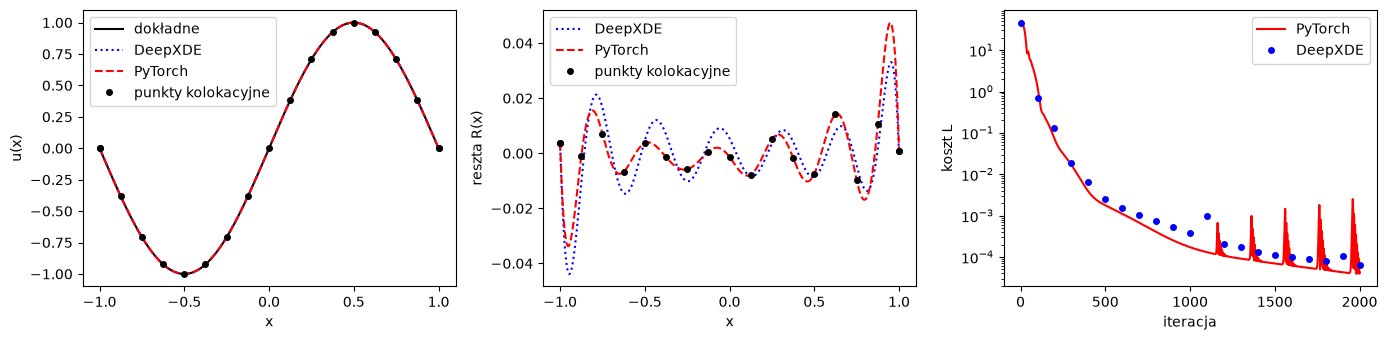

In [10]:
def compare(model, hist, label, X):
    x_t = torch.linspace(-1, 1, 500).reshape(-1, 1).requires_grad_(True)
    u = model(x_t)
    u_x = torch.autograd.grad(u, x_t, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_t, torch.ones_like(u_x))[0]
    R = (EA * u_xx + math.pi**2 * torch.sin(math.pi * x_t)).detach().cpu().numpy()
    u = u.detach().cpu().numpy()
    xs = x_t.detach().cpu().numpy()
    # wartości w punktach kolokacyjnych
    u_c = model(X)
    R_c = pde(X, u_c).detach().cpu().numpy()
    u_c = u_c.detach().cpu().numpy()
    xc = X.detach().cpu().numpy()
    L_dde = np.sum(losshistory.loss_train, axis=1)

    fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
    a = ax[0]
    if USE_EXACT:
        a.plot(xs, u_exact(xs), "k-", label="dokładne")
    a.plot(xs, u_dde, "b:", label="DeepXDE")
    a.plot(xs, u, "r--", label=label)
    a.plot(xc, u_c, "ko", ms=4, label="punkty kolokacyjne")
    a.set(xlabel="x", ylabel="u(x)"); a.legend()

    a = ax[1]
    a.plot(xs, R_dde, "b:", label="DeepXDE")
    a.plot(xs, R, "r--", label=label)
    a.plot(xc, R_c, "ko", ms=4, label="punkty kolokacyjne")
    a.set(xlabel="x", ylabel="reszta R(x)"); a.legend()

    a = ax[2]
    a.semilogy(hist, "r-", label=label)
    a.semilogy(losshistory.steps, L_dde, "bo", ms=4, label="DeepXDE")
    a.set(xlabel="iteracja", ylabel="koszt L"); a.legend()
    fig.tight_layout()
    print(f"max różnica kosztu {label} vs DeepXDE:", np.max(np.abs(np.array(hist)[losshistory.steps] - L_dde)))

compare(model, hist, "PyTorch", X)

## 3. Dodatek: PyTorch vs DeepXDE 1:1

In [6]:
torch.manual_seed(SEED)

class PINN_11(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.dense1 = self.layer(1, WIDTH)
        self.dense2 = self.layer(WIDTH, WIDTH)
        self.dense3 = self.layer(WIDTH, WIDTH)
        self.out = self.layer(WIDTH, 1)
        self.act = torch.nn.Tanh()

    # UWAGA 1: inicjalizacja następuje od razu przy tworzeniu warstwy, a nie po utworzeniu wszystkich warstw
    @staticmethod
    def layer(n_in, n_out):
        layer = torch.nn.Linear(n_in, n_out)
        torch.nn.init.xavier_uniform_(layer.weight)
        torch.nn.init.zeros_(layer.bias)
        return layer

    def forward(self, x):
        x = self.act(self.dense1(x))
        x = self.act(self.dense2(x))
        x = self.act(self.dense3(x))
        return self.out(x)

def pde_11(x, u):
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    p = math.pi**2 * torch.sin(math.pi * x)   # obciążenie p(x)
    return EA * u_xx + p

def loss_11(model, X, n_bc):
    u = model(X)
    R = pde_11(X, u)
    L_pde = torch.mean(R[n_bc:] ** 2)
    L_bc = torch.mean(u[:n_bc] ** 2)
    return w_pde * L_pde + w_bc * L_bc

def van_der_corput(n):
    t = []
    for i in range(1, n + 1):
        f, r, k = 1.0, 0.0, i
        while k > 0:
            f /= 2
            r += f * (k % 2)
            k //= 2
        t.append(r)
    return np.array(t)

model_11 = PINN_11()
opt_11 = torch.optim.Adam(model_11.parameters(), lr=LR)
x_bc_11 = np.array([-1.0, 1.0])
# UWAGA 2: punkty kolokacyjne są generowane w rozkładzie Hammersleya
x_col_11 = 2 * van_der_corput(N_COL) - 1
x_all_11 = np.concatenate([x_bc_11, x_col_11])
X_11 = torch.tensor(np.concatenate([x_bc_11, x_all_11]), dtype=torch.float32).reshape(-1, 1).requires_grad_(True)
n_bc_11 = len(x_bc_11)
print("punkty identyczne z DeepXDE:", np.array_equal(X_11.detach().cpu().numpy(), data.train_x))

hist_11 = []
for it in range(ITERATIONS):
    opt_11.zero_grad()
    L = loss_11(model_11, X_11, n_bc_11)
    L.backward()
    opt_11.step()
    hist_11.append(L.item())
    if it % (ITERATIONS // 20) == 0:
        print(f"{it:6d}  L = {L.item():.3e}")
hist_11.append(loss_11(model_11, X_11, n_bc_11).item())

punkty identyczne z DeepXDE: True
     0  L = 4.353e+02
   100  L = 5.146e-02
   200  L = 4.420e-02
   300  L = 4.144e-02
   400  L = 3.842e-02
   500  L = 3.528e-02
   600  L = 3.213e-02
   700  L = 2.906e-02
   800  L = 2.613e-02
   900  L = 2.337e-02
  1000  L = 2.080e-02
  1100  L = 1.843e-02
  1200  L = 1.627e-02
  1300  L = 1.432e-02
  1400  L = 1.256e-02
  1500  L = 1.098e-02
  1600  L = 9.590e-03
  1700  L = 8.351e-03
  1800  L = 7.279e-03
  1900  L = 7.281e-03


max różnica kosztu PyTorch (1:1) vs DeepXDE: 0.0


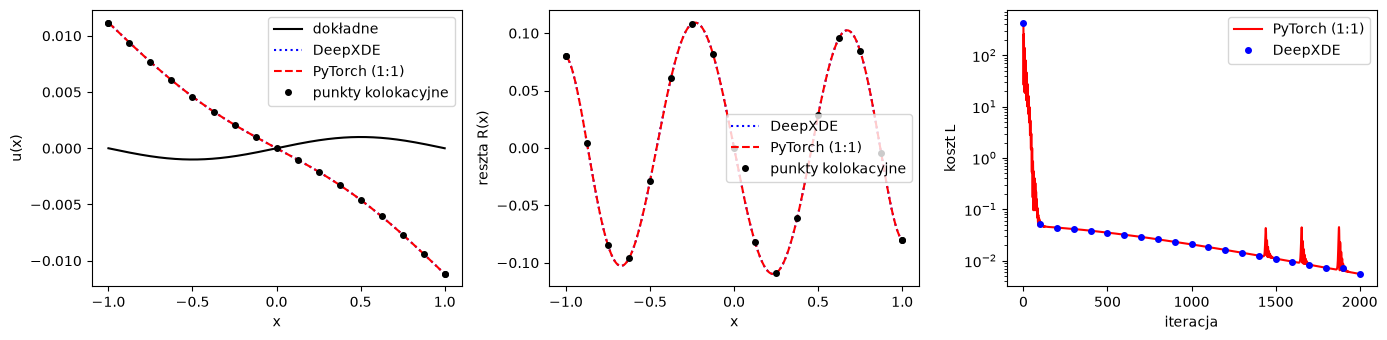

In [7]:
compare(model_11, hist_11, "PyTorch (1:1)", X_11)

## Wnioski

PyTorch = DeepXDE co do bitu. Rozwiązanie trzecie od drugiego różni się:

1. **Kolejnością inicjalizacji wag** — `torch.nn.Linear` przy tworzeniu już zużywa liczby losowe; DeepXDE: warstwa → Glorot → warstwa…, rozw. 2: najpierw wszystkie warstwy. To samo ziarno → inne wagi startowe.
2. **Punktami kolokacyjnymi** — Hammersley vs `linspace` (dla `N_COL` = 15 ten sam zbiór, inna kolejność). Gradient po wagach to suma wkładów od punktów, a w float32 wynik sumy zależy od kolejności dodawania.